# C-MAPSS Exploratory Data Analysis (EDA)

In this notebook, we analyze the NASA C-MAPSS turbofan engine degradation dataset (specifically FD001 and FD002/FD004 subsets).

Our goal is to:
1. Understand the sensor distributions over cycles.
2. Identify uninformative (constant/flat) sensors in FD001.
3. Compute Pearson correlation coefficients between sensors and the Remaining Useful Life (RUL).
4. Visualize operating condition regimes for FD002/FD004.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Set style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = '../data/raw/cmapss'

## 1. Load FD001 Dataset

The dataset lacks headers. We define columns based on the C-MAPSS documentation.
- `unit_nr`: Engine ID
- `time_cycles`: Cycle number
- `setting_1`, `setting_2`, `setting_3`: Three operational settings
- `s_1` to `s_21`: 21 sensor measurements

In [2]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Load train data for FD001
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_FD001.txt'), sep=r'\s+', header=None, names=col_names)
print(f'FD001 Train Shape: {train_df.shape}')
train_df.head()

FD001 Train Shape: (20631, 26)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Compute Remaining Useful Life (RUL)

For the training set, the run-to-failure trajectory means the final cycle of an engine represents its failure point. Therefore, the RUL at cycle $t$ is:
$$RUL_t = max(cycles) - t$$

In [3]:
# Compute max cycle per engine
max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']

# Merge back and compute RUL
train_df = train_df.merge(max_cycles, on='unit_nr')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)
train_df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 3. Visualize Sensor Trajectories

Let's plot sensor readings over time for a few representative engine units to see how sensors change as failure approaches.

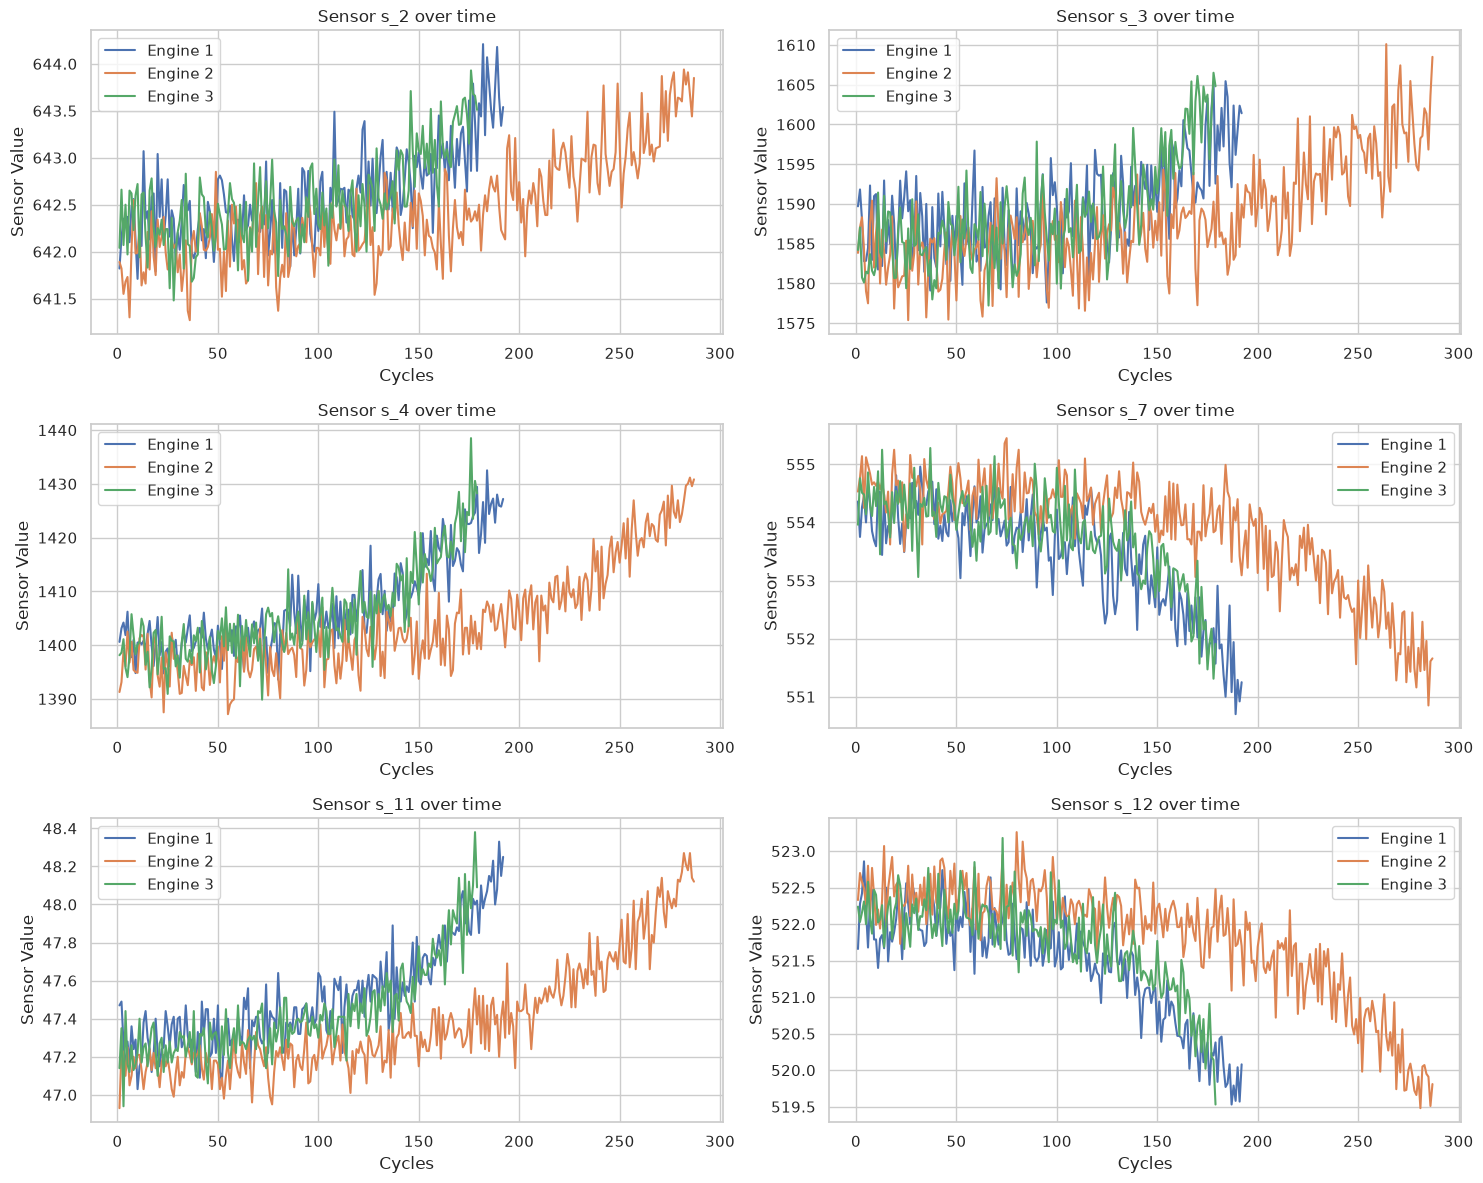

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()
example_engines = [1, 2, 3]
selected_sensors = ['s_2', 's_3', 's_4', 's_7', 's_11', 's_12']

for i, sensor in enumerate(selected_sensors):
    for engine in example_engines:
        engine_data = train_df[train_df['unit_nr'] == engine]
        axes[i].plot(engine_data['time_cycles'], engine_data[sensor], label=f'Engine {engine}')
    axes[i].set_title(f'Sensor {sensor} over time')
    axes[i].set_xlabel('Cycles')
    axes[i].set_ylabel('Sensor Value')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 4. Identify Constant/Flat Sensors

Sensors that do not change over time provide no predictive power for RUL. Let's find sensors with near-zero standard deviation.

In [5]:
# Calculate standard deviation for all sensors
sensor_stds = train_df[sensor_names].std()
flat_sensors = sensor_stds[sensor_stds < 1e-4].index.tolist()
print('Standard Deviation of Sensors:')
print(sensor_stds.round(4))
print(f'\nFlat/Constant Sensors to drop in FD001: {flat_sensors}')

Standard Deviation of Sensors:
s_1      0.0000
s_2      0.5001
s_3      6.1311
s_4      9.0006
s_5      0.0000
s_6      0.0014
s_7      0.8851
s_8      0.0710
s_9     22.0829
s_10     0.0000
s_11     0.2671
s_12     0.7376
s_13     0.0719
s_14    19.0762
s_15     0.0375
s_16     0.0000
s_17     1.5488
s_18     0.0000
s_19     0.0000
s_20     0.1807
s_21     0.1083
dtype: float64

Flat/Constant Sensors to drop in FD001: ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']


## 5. Compute Correlation with RUL

Let's compute Pearson correlation between each active sensor and the target RUL.

/tmp/ipykernel_42623/3892745197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


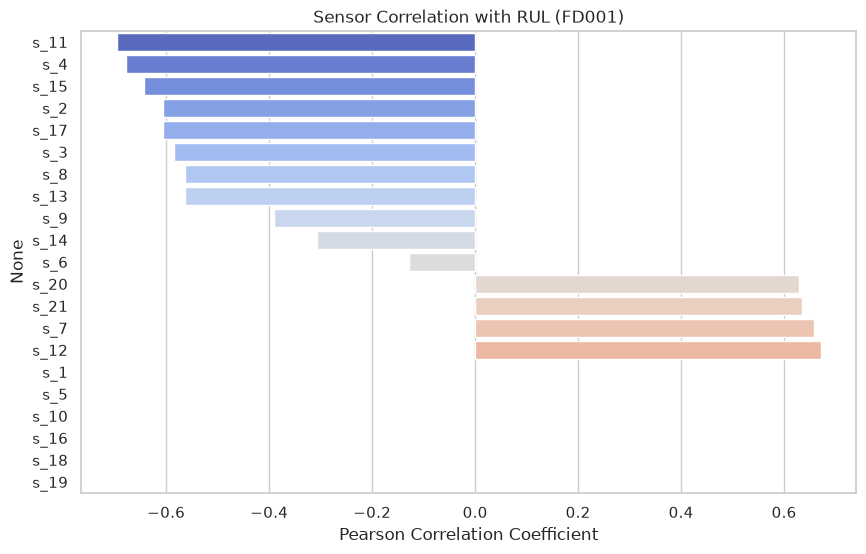

Sensor correlations with RUL:
s_11   -0.6962
s_4    -0.6789
s_15   -0.6427
s_2    -0.6065
s_17   -0.6062
s_3    -0.5845
s_8    -0.5640
s_13   -0.5626
s_9    -0.3901
s_14   -0.3068
s_6    -0.1283
s_20    0.6294
s_21    0.6357
s_7     0.6572
s_12    0.6720
s_1        NaN
s_5        NaN
s_10       NaN
s_16       NaN
s_18       NaN
s_19       NaN
Name: RUL, dtype: float64


In [6]:
correlations = train_df[sensor_names + ['RUL']].corr()['RUL'].sort_values()
correlations = correlations.drop('RUL')

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Sensor Correlation with RUL (FD001)')
plt.xlabel('Pearson Correlation Coefficient')
plt.show()

print('Sensor correlations with RUL:')
print(correlations.round(4))

## 6. Analyze Operating Regimes (FD002)

FD002 and FD004 are simulated under 6 operating conditions. Let's load FD002 and visualize these regimes using the 3 operational settings.

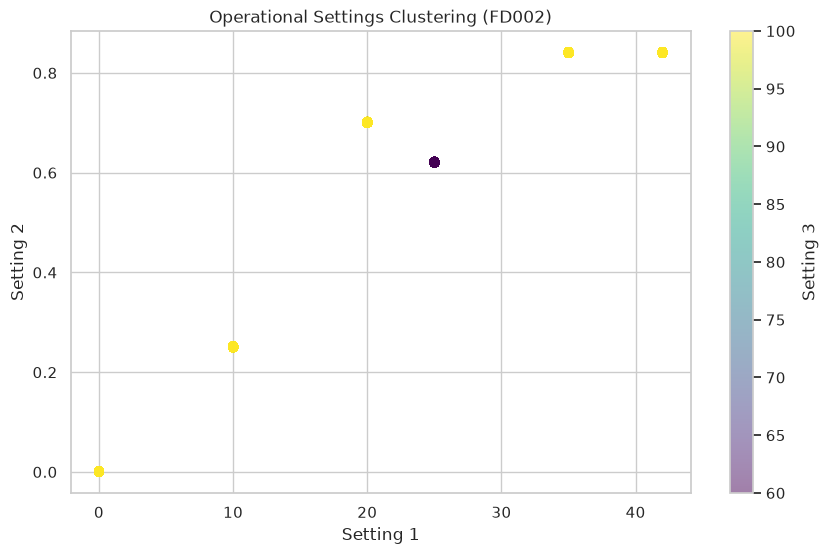

In [7]:
# Load FD002 data
train_fd002 = pd.read_csv(os.path.join(DATA_DIR, 'train_FD002.txt'), sep=r'\s+', header=None, names=col_names)

# Visualizing operational settings clusters
plt.figure(figsize=(10, 6))
plt.scatter(train_fd002['setting_1'], train_fd002['setting_2'], c=train_fd002['setting_3'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Setting 3')
plt.title('Operational Settings Clustering (FD002)')
plt.xlabel('Setting 1')
plt.ylabel('Setting 2')
plt.show()

## 7. Cluster Regimes with KMeans

We use KMeans to explicitly identify the 6 regimes, and observe the average values of some sensors to show how operational regimes shift sensor baseline scales.

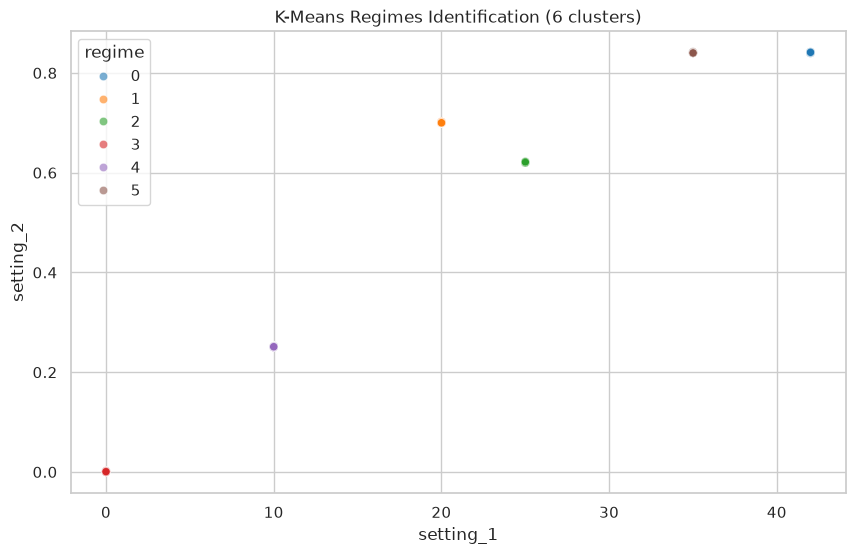

Scale shifts across regimes:
             s_2        s_3        s_4
regime                                
0       549.7049  1354.4630  1127.8025
1       607.5649  1485.5875  1253.1185
2       536.8651  1262.6848  1050.3209
3       642.6787  1590.4211  1408.8609
4       604.9134  1502.0121  1311.2531
5       555.7992  1366.7134  1131.5307


In [8]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train_fd002['regime'] = kmeans.fit_predict(train_fd002[setting_names])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_fd002, x='setting_1', y='setting_2', hue='regime', palette='tab10', alpha=0.6)
plt.title('K-Means Regimes Identification (6 clusters)')
plt.show()

# Show average sensor values across regimes to show the scale shifts
regime_grouped = train_fd002.groupby('regime')[['s_2', 's_3', 's_4']].mean()
print('Scale shifts across regimes:')
print(regime_grouped.round(4))